## Exercise: Support vector machines and model tuning

#### In this exercise, we will explore the use of `support vector machines` and model tuning techniques using the scikit-learn library. Specifically, we will implement `SVM Classifier` models with both linear and radial basis function kernels. We will visualise the decision boundaries created by these models to understand their effectiveness in classifying data points. Additionally, we will utilise hyperparameter tuning with `GridSearchCV` to optimise the SVM model's performance by finding the best combination of hyperparameters

### Learning Objectives
#### By the end of this exercise, you should be able to:
#### - Implement SVM classifier models with linear and RBF kernels using scikit-learn.
#### - Visualise decision boundaries created by SVM models to assess their effectiveness.
#### - Understand the importance of hyperparameter tuning and utilise techniques like GridSearchCV to optimise model performance

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.datasets import make_gaussian_quantiles

# Set the feature dimensionality
p = 4

# Construct the dataset
X, y = make_gaussian_quantiles(
    cov=3.,
    n_samples=1000,
    n_features=p,
    n_classes=2,
    random_state=1
)

In [3]:
# get training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

## Exercises

### Exercise 1: Fit a SVM classifier with a linear decision boundary

#### We have a dataset with multiple features, and we want to classify the data into two classes using a support vector machine with a linear decision boundary. By fitting an SVC model with a linear kernel to the training data, we aim to create a decision boundary that separates the classes effectively:

#### For this exercise, do the following:
#### - Instantiate an SVC classifier with a linear kernel
#### - Fit the classifier to the training data created above and make predictions on the test data
#### - Print the accuracy score and classification report to evaluate the model's performance

In [4]:
from sklearn.svm import SVC

svc = SVC(kernel='linear')
svc.fit(X_train, y_train)

y_pred = svc.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
class_rpt = classification_report(y_test, y_pred)

print("Model Accuracy: ", accuracy)
print("Model Classification Score: \n", class_rpt)

Model Accuracy:  0.45666666666666667
Model Classification Score: 
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       163
           1       0.46      1.00      0.63       137

    accuracy                           0.46       300
   macro avg       0.23      0.50      0.31       300
weighted avg       0.21      0.46      0.29       300



### Exercise 2: Plot the decision boundary for the SVC

#### After fitting the SVM classifier with a linear kernel, we observe that the accuracy score was not high as expected. To gain insights into the model's performance and understand why the accuracy was lower, we decided to vosualise the decision boundary. By plotting the decision boundary in a two-dimensional space, we aim to visually inspect how well the linear boundary separates the classes.

#### For this exercise, do the following:
#### - Plot the decision boundary for the SVM classifier with a linear kernel.

#### Based on the visualisation of the decision boundary, what can we infer about the effectiveness of the linear boundary in separating the classes?

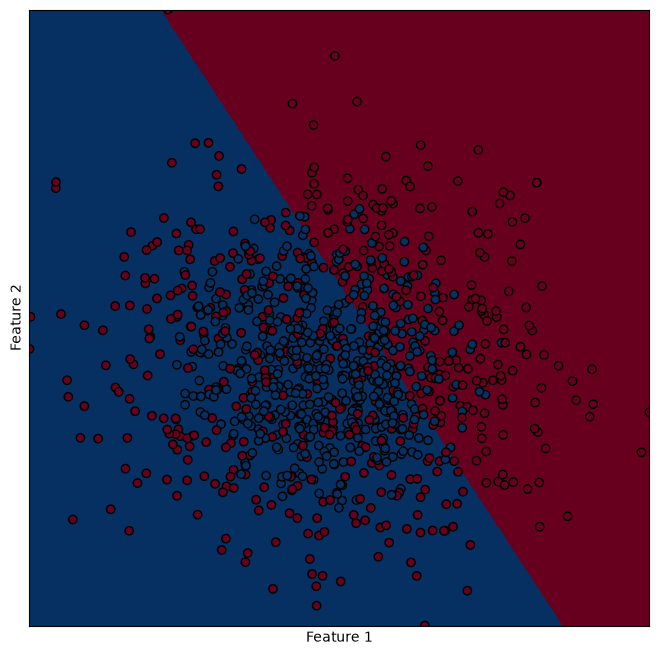

In [5]:
i = 0 # Feature 1
j = 1 # Feature 2

svc.fit(X[:, [i, j]], y)
fig = plt.figure(figsize=(8, 8))
ax1 = fig.add_subplot(111)

x_min, x_max = X[:, i].min(), X[:, i].max()
y_min, y_max = X[:, j].min(), X[:, j].max()
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 1000), np.linspace(y_min, y_max, 1000))

y_hat = svc.predict(np.concatenate((xx.reshape(-1,1), yy.reshape(-1,1)), axis=1))
y_hat = y_hat.reshape(xx.shape)

ax1.pcolormesh(xx, yy, y_hat, cmap='RdBu_r')
ax1.scatter(X[:, i], X[:, j], c=y, edgecolors='k', cmap='RdBu_r')
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
ax1.set_xlim(xx.min(), xx.max())
ax1.set_ylim(yy.min(), yy.max())
ax1.set_xticks(())
ax1.set_yticks(())
plt.show()

### Exercise 3: Fit a SVC classifier with a non-linear decision boundary

#### Recognising the limitations of the linear decision boundary, fit an SVC model with an RBF kernel to the training data and evaluate its performance on the test set.

#### For this exercise, do the following:
#### - Use the provided code to fit an SVC model with an RBF kernel to the training data.
#### - Make predictions on the test data.
#### - Print the accuracy score and classification report to evaluate the performance of the model

In [6]:
svc_rbf = SVC(kernel='rbf')

svc_rbf.fit(X_train, y_train)

y_pred = svc_rbf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
class_rpt = classification_report(y_test, y_pred)

print("Model Accuracy: ", accuracy)
print("Model Classification Score: \n", class_rpt)

Model Accuracy:  0.9766666666666667
Model Classification Score: 
               precision    recall  f1-score   support

           0       0.98      0.98      0.98       163
           1       0.98      0.97      0.97       137

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300



### Exercise 4: Plot the decision boundary for the SVC using the non-linear RBF kernel

#### After observing a significant improvement in accuracy with the RBF kernel, your task is to visualise the decision boundary created by the non-linear RBF kernel in a two-dimensional space.

#### For this exercise, do the following:
#### - Plot the decision boundary for the SVM classifier with an RBF kernel.
#### - Compare the decision boundary visualisation of the RBF kernel with the Linear kernel.
#### - Make observations about the difference between the two visualisations.

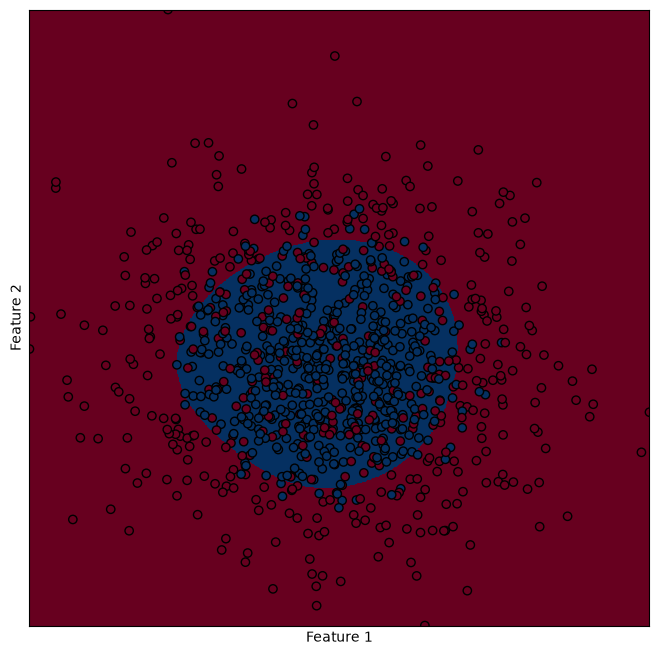

In [7]:
i = 0 # Feature 1
j = 1 # Feature 2

svc_rbf.fit(X[:, [i, j]], y)
fig = plt.figure(figsize=(8, 8))
ax1 = fig.add_subplot(111)

x_min, x_max = X[:, i].min(), X[:, i].max()
y_min, y_max = X[:, j].min(), X[:, j].max()
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 1000), np.linspace(y_min, y_max, 1000))

y_hat = svc_rbf.predict(np.concatenate((xx.reshape(-1,1), yy.reshape(-1,1)), axis=1))
y_hat = y_hat.reshape(xx.shape)

ax1.pcolormesh(xx, yy, y_hat, cmap='RdBu_r')
ax1.scatter(X[:, i], X[:, j], c=y, edgecolors='k', cmap='RdBu_r')
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
ax1.set_xlim(xx.min(), xx.max())
ax1.set_ylim(yy.min(), yy.max())
ax1.set_xticks(())
ax1.set_yticks(())
plt.show()

### Exercise 5: Tuning an SVM model

#### To further optimise the SVM model's performance, utilise hyperparameter tuning using GridSearchCV. Perform a grid search to find the best combination of hyperparameters that maximises model accuracy on the test data.

#### For this exercise, do the following:
#### - Define a parameter grid containing different values for the kernel, C, and gamma parameters.
#### - Instantiate an SVC classifier.
#### - Perform a grid search using GridSearchCV with the defined parameter grid.
#### - Fit the grid search object to the training data.
#### - Make predictions on the test data using the best-tuned model obtained from the grid search.
#### - Print the accuracy score to evaluate the performance of the tuned model

In [8]:
svc_tuned = SVC()

param_grid = {
    'kernel': ['linear', 'rbf', 'poly'],
    'C': [0.1, 1, 10],
    'gamma': [0.01, 0.1, 1]
}

grid_search = GridSearchCV(
    estimator=svc_tuned,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'
)

grid_search.fit(X_train, y_train)

best_svc = grid_search.best_estimator_

y_pred = best_svc.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print('Accuracy score for the tuned model: ', accuracy)

Accuracy score for the tuned model:  0.98
